# Micrograd: Building Autograd From Scratch

Following Andrej Karpathy's *"The spelled-out intro to neural networks and backpropagation: building micrograd"* (Zero to Hero, video 1). Built a scalar autograd engine, a tiny MLP on top of it, and train the MLP with gradient descent on a 4-example toy dataset. By the end, our gradients match PyTorch's autograd exactly.

In [30]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

plt.style.use('dark_background')

In [31]:
def f(x):
    return 3*x**2 - 4*x + 5

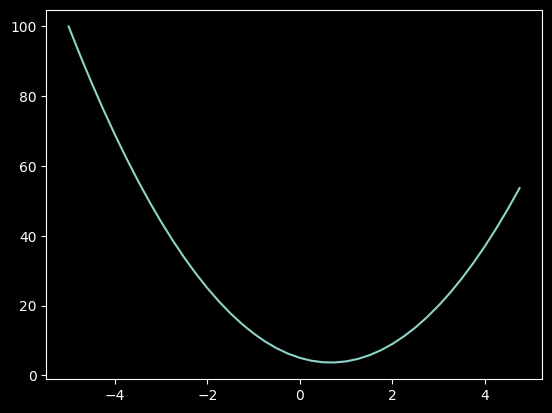

In [32]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [33]:
# Numerical derivative: (f(x+h) - f(x))/h approaches f'(x) as h → 0.
# At x=3: f'(3) = 6(3) - 4 = 14 — the cell below confirms it.
h = 0.00000000000001
x = 3.0
(f(x + h) - f(x)) / h

14.210854715202004

In [34]:
# Same idea for a multivariable expression d = a*b + c.
# Numerically computing ∂d/∂b: d/db (a*b + c) = a = 2.0.
h = 0.00000001

a = 2.0
b = -3.0
c = 10.0

d1 = a * b + c
b += h
d2 = a * b + c

print("d1: ", d1)
print("d2: ", d2)
print("Slope: ", (d2 - d1) / h)

d1:  4.0
d2:  4.00000002
Slope:  1.999999987845058


In [35]:
class Value:
    """A scalar with autograd: tracks data, gradient, and the op tree that produced it."""
    def __init__(self, data, _children=(), _op='',  label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self.label = label
        self.prev = set(_children)
        self._op = _op
    
    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        
        def _backward():
            # d/dx (x + y) = 1 for both — gradient flows through unchanged
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward
        return out
    
    def __radd__(self, other):
        # Called when the left operand isn't a Value (e.g. sum() starts with int 0)
        return self + other
    
    def __neg__(self):
        return self * -1
    
    def __sub__(self, other):
        # Composed from existing ops: a - b == a + (-b)
        return self + (-other)

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        
        def _backward():
            # Product rule: d/dx (x*y) = y, d/dy (x*y) = x
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out
    
    def __rmul__(self, other):
        return self * other
    
    def __truediv__(self, other):
        return self * other**-1
    
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "Only supporting int/float powers for now"
        out = Value(self.data ** other, (self,), f'**{other}')
        
        def _backward():
            # Power rule: d/dx (x**n) = n * x**(n-1)
            self.grad += other * (self.data ** (other - 1)) * out.grad
        out._backward = _backward
        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,), 'exp')

        def _backward():
            # d/dx e^x = e^x, which is exactly out.data
            self.grad += out.data * out.grad
        out._backward = _backward
        
        return out
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self,), 'tanh')

        def _backward():
            # d/dx tanh(x) = 1 - tanh(x)^2
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        
        return out
    
    def backward(self):
        # Topological sort: visit each node only after all its children
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v.prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        # Seed dL/dL = 1, then chain-rule backward through the topo-sorted graph
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()


In [36]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v.prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(
        format='svg',
        graph_attr={'rankdir': 'LR', 'bgcolor': '#1e1e1e'},
        node_attr={'style': 'filled', 'fillcolor': '#2d2d2d', 'color': '#888', 'fontcolor': 'white'},
        edge_attr={'color': '#aaa'},
    )
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    return dot

In [37]:
# inputs
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# Weights
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# Bias
b = Value(6.8813735870195432, label='b')

# x1*w1 + x2*w2 + b
x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

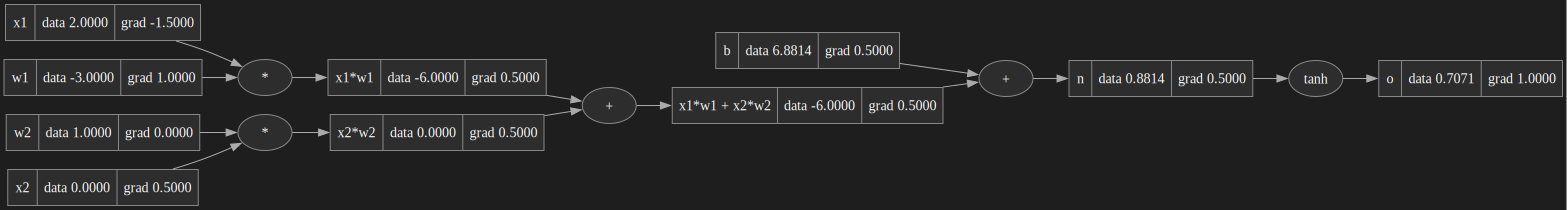

In [38]:
o.grad = 1.0
o.backward()

draw_dot(o)

In [39]:
# Sanity check: redo the forward+backward in PyTorch and confirm gradients match ours.
# Any mismatch beyond floating-point noise would mean our autograd has a bug.
import torch

x1 = torch.tensor([2.0]).double()               ; x1.requires_grad = True
x2 = torch.tensor([0.0]).double()               ; x2.requires_grad = True
w1 = torch.tensor([-3.0]).double()              ; w1.requires_grad = True
w2 = torch.tensor([1.0]).double()               ; w2.requires_grad = True
b = torch.tensor([6.8813735870195432]).double() ; b.requires_grad = True
n = x1 * w1 + x2 * w2 + b
o = torch.tanh(n)

print("o: ", o.data.item())
o.backward()

print("== PyTorch gradients ==")
print("x1.grad: ", x1.grad.item())
print("x2.grad: ", x2.grad.item())
print("w1.grad: ", w1.grad.item())
print("w2.grad: ", w2.grad.item())

o:  0.7071066904050358
== PyTorch gradients ==
x1.grad:  -1.5000003851533106
x2.grad:  0.5000001283844369
w1.grad:  1.0000002567688737
w2.grad:  0.0


In [40]:
class Neuron:
    """A single neuron: w · x + b, passed through tanh."""
    def __init__(self, nin):
        self.w = [Value(np.random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(np.random.uniform(-1, 1))

    def __call__(self, x):
        # sum(..., start=self.b) starts the accumulator at the bias
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out
    
    def parameters(self):
        return self.w + [self.b]

class Layer:
    """A layer is a list of neurons; calling it on x returns each neuron's output."""
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        # Convenience: when there's only one output neuron, return the bare Value
        # rather than a 1-element list - keeps downstream loss expressions clean.
        return outs[0] if len(outs) == 1 else outs
    
    def parameters(self):
        params = []
        for neuron in self.neurons:
            params.extend(neuron.parameters())
        return params
    
class MLP:
    """A multi-layer perceptron: chain of Layers, with all parameters flattened."""
    def __init__(self, nin, nouts):
        # sz = [nin, nouts[0], nouts[1], ...] - input size of each layer
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    
    def parameters(self):
        params = []
        for layer in self.layers:
            params.extend(layer.parameters())
        return params

In [41]:
# Build the network: 3 inputs → 4 hidden → 4 hidden → 1 output.
x = [2.0, 3.0, -1.0]
model = MLP(3, [4, 4, 1])
model(x)

Value(data=-0.2208424780111521)

In [42]:
# 4 example training points, with targets.
inputs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]
targets = [1.0, -1.0, -1.0, 1.0]


for k in range(25):
    # Forward pass: predict for every input, compute mean-squared error loss
    predictions = [model(x) for x in inputs]
    loss = sum((pred - target) ** 2 for target, pred in zip(targets, predictions))

    # Backward pass: zero grads first, then accumulate them via backward()
    for parameter in model.parameters():
        parameter.grad = 0.0
    loss.backward()

    # Gradient descent step: nudge each parameter against its gradient
    for parameter in model.parameters():
        parameter.data -= 0.05 * parameter.grad

    print(f"Pass: {k + 1} - loss: {loss.data}")

Pass: 1 - loss: 2.412796623041048
Pass: 2 - loss: 1.3795778987781202
Pass: 3 - loss: 0.5454242748606475
Pass: 4 - loss: 0.2372613802385513
Pass: 5 - loss: 0.18113004681797393
Pass: 6 - loss: 0.14475191581039065
Pass: 7 - loss: 0.11954487655177885
Pass: 8 - loss: 0.10119777069762617
Pass: 9 - loss: 0.08732895529842719
Pass: 10 - loss: 0.07652667845572349
Pass: 11 - loss: 0.06790625604119682
Pass: 12 - loss: 0.060887733869370804
Pass: 13 - loss: 0.055076491419114734
Pass: 14 - loss: 0.05019548075482331
Pass: 15 - loss: 0.04604494644829445
Pass: 16 - loss: 0.04247751965479008
Pass: 17 - loss: 0.039382287701032304
Pass: 18 - loss: 0.03667430015156658
Pass: 19 - loss: 0.03428747525177166
Pass: 20 - loss: 0.03216969419806822
Pass: 21 - loss: 0.03027933880117188
Pass: 22 - loss: 0.028582802958363532
Pass: 23 - loss: 0.027052674458608324
Pass: 24 - loss: 0.0256663866691473
Pass: 25 - loss: 0.0244052050626488
